# Wikidata Journal Article Counter

Created by [Matt Artz](https://www.mattartz.me/) | [GitHub](https://github.com/MattArtzAnthro) | [ORCID](https://orcid.org/0000-0002-3822-1429)

---

## What This Notebook Does

Queries the Wikidata scholarly endpoint to count how many articles are indexed for a set of academic journals. Useful for assessing coverage, identifying gaps, and prioritizing data contribution efforts.

Accepts a CSV of journal Wikidata Q-identifiers (or uses a built-in list of 21 AAA journals) and returns article counts with summary statistics and visualizations.

**Endpoint note**: Since May 2025, scholarly articles live on `query-scholarly.wikidata.org`, separate from the main Wikidata endpoint. This notebook queries the scholarly endpoint directly.

## Workflow

1. **Load journals**: Use the default AAA list or upload a CSV with journal QIDs
2. **Configure**: Set rate limiting, retries, and timeout
3. **Query**: SPARQL queries count articles per journal on the scholarly endpoint
4. **Review**: Summary statistics and bar chart visualization
5. **Export**: Download results as timestamped CSV

## Citation

If you use this notebook, please cite:

> Artz, M. (2026). Wikidata Journal Article Counter. GitHub. https://github.com/MattArtzAnthro/wikidata-tools

*A citable DOI will be available via Zenodo.*

## License

[CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/)

## Setup and Installation

*Install required Python packages and import necessary libraries for SPARQL queries, data processing, and visualization. Run this cell first to ensure all dependencies are available.*

In [ ]:
# Install required packages
!pip install -q requests pandas matplotlib ipywidgets

# Import libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import re
import io
from datetime import datetime
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# Colab file upload/download (optional — works without it)
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configure matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Setup complete.")

## Style Configuration

*Define consistent styling for the interactive interface elements.*

In [2]:
COLORS = {
    'primary_bg': '#E7ECEF',
    'primary_text': '#274C77',
    'interactive': '#6096BA',
    'secondary_bg': '#A3CEF1',
    'neutral': '#8B8C89',
    'white': '#FFFFFF'
}

WIDGET_STYLE = {'description_width': '150px'}
BUTTON_LAYOUT = widgets.Layout(width='200px', height='40px')

def styled_container(content, title, emoji=""):
    return HTML(f'<div style="background-color: {COLORS["primary_bg"]}; border-left: 5px solid {COLORS["primary_text"]}; border-radius: 10px; padding: 20px; margin: 10px 0;"><h3 style="color: {COLORS["primary_text"]}; margin-top: 0;">{emoji} {title}</h3>{content}</div>')

print("Style configuration loaded.")

Style configuration loaded.


## Wikidata Query Functions

*Core functions for constructing SPARQL queries that access Wikidata's scholarly graph via federation. The 2025 WDQS graph split requires querying `query-scholarly.wikidata.org` for bibliographic data.*

In [ ]:
# Main Wikidata endpoint (for federated queries)
WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"

# Scholarly endpoint (where bibliographic data lives post-2025 split)
SCHOLARLY_ENDPOINT = "https://query-scholarly.wikidata.org/sparql"

USER_AGENT = "WikidataJournalArticleCounter/1.0 (https://www.mattartz.me/)"

def extract_qid(url_or_qid):
    """Extract Q-identifier from a Wikidata URL or return the QID if already in Q format."""
    if isinstance(url_or_qid, str):
        if 'wikidata.org' in url_or_qid:
            match = re.search(r'Q\d+', url_or_qid)
            if match:
                return match.group()
        elif url_or_qid.startswith('Q'):
            return url_or_qid
    return None

def build_article_count_query_direct(journal_qid):
    """
    Build a direct SPARQL query for the scholarly endpoint.
    Uses p:P1433/ps:P1433 (statement path) rather than wdt:P1433 (truthy projection)
    for more robust results.
    """
    query = f"""
    SELECT (COUNT(DISTINCT ?work) AS ?workCount) WHERE {{
      ?work p:P1433/ps:P1433 wd:{journal_qid} .
    }}
    """
    return query

def query_wikidata(query, endpoint=None, max_retries=3, timeout=120):
    """Execute a SPARQL query against a Wikidata endpoint with retries."""
    if endpoint is None:
        endpoint = SCHOLARLY_ENDPOINT

    headers = {
        'User-Agent': USER_AGENT,
        'Accept': 'application/sparql-results+json'
    }

    for attempt in range(max_retries):
        try:
            response = requests.get(
                endpoint,
                params={'query': query, 'format': 'json'},
                headers=headers,
                timeout=timeout
            )
            response.raise_for_status()
            return response.json()
        except requests.exceptions.Timeout:
            print(f"      Timeout on attempt {attempt + 1}/{max_retries}, retrying...")
            if attempt < max_retries - 1:
                time.sleep(5 * (attempt + 1))
        except requests.exceptions.RequestException as e:
            print(f"      Error on attempt {attempt + 1}/{max_retries}: {str(e)[:80]}")
            if attempt < max_retries - 1:
                time.sleep(5 * (attempt + 1))
    return None

def get_article_count(journal_qid):
    """Get the count of scholarly works published in a journal via the scholarly endpoint."""
    query = build_article_count_query_direct(journal_qid)
    result = query_wikidata(query, endpoint=SCHOLARLY_ENDPOINT)

    if result and 'results' in result and 'bindings' in result['results']:
        bindings = result['results']['bindings']
        if bindings:
            return int(bindings[0]['workCount']['value'])
    return -1

print("Query functions loaded.")
print(f"  Scholarly endpoint: {SCHOLARLY_ENDPOINT}")

## Data Input

*Load journal data from the default AAA journals list or upload your own CSV file.*

In [4]:
DEFAULT_JOURNALS_CSV = """journal,journalLabel,issns
http://www.wikidata.org/entity/Q4579783,American Anthropologist,"1548-1433, 0002-7294"
http://www.wikidata.org/entity/Q15762644,American Ethnologist,"1548-1425, 0094-0496"
http://www.wikidata.org/entity/Q27724868,Annals of Anthropological Practice,"2153-9588, 2153-957X"
http://www.wikidata.org/entity/Q15754091,Anthropology and Education Quarterly,"1548-1492, 0161-7761"
http://www.wikidata.org/entity/Q15755065,Anthropology and Humanism,"1548-1409, 1559-9167"
http://www.wikidata.org/entity/Q4773909,Anthropology of Consciousness,"1556-3537, 1053-4202"
http://www.wikidata.org/entity/Q15760484,Anthropology of Work Review,"0883-024X, 1548-1417"
http://www.wikidata.org/entity/Q15760478,Archaeological Papers of the AAA,"1551-823X, 1551-8248"
http://www.wikidata.org/entity/Q15761559,City & Society,"1548-744X, 0893-0465"
http://www.wikidata.org/entity/Q4987840,Culture Agriculture Food and Environment,"2153-9553, 2153-9561"
http://www.wikidata.org/entity/Q15759840,Economic Anthropology,2330-4847
http://www.wikidata.org/entity/Q15761969,Ethos,"1548-1352, 0091-2131"
http://www.wikidata.org/entity/Q107321855,Feminist Anthropology,2643-7961
http://www.wikidata.org/entity/Q5537805,General Anthropology,"1537-1727, 1939-3466"
http://www.wikidata.org/entity/Q62955374,Journal for the Anthropology of North America,2475-5389
http://www.wikidata.org/entity/Q16842640,Journal of Latin American and Caribbean Anthropology,"1935-4940, 1935-4932"
http://www.wikidata.org/entity/Q15757220,Journal of Linguistic Anthropology,"1055-1360, 1548-1395"
http://www.wikidata.org/entity/Q15759529,Medical Anthropology Quarterly,"0745-5194, 1548-1387"
http://www.wikidata.org/entity/Q15752491,Museum Anthropology,"0892-8339, 1548-1379"
http://www.wikidata.org/entity/Q63871800,PoLAR,"1555-2934, 1081-6976"
http://www.wikidata.org/entity/Q27722507,Visual Anthropology Review,"1058-7187, 1548-7458"
"""

journals_df = None

data_source = widgets.RadioButtons(
    options=['Use default AAA journals list', 'Upload custom CSV'],
    value='Use default AAA journals list',
    description='Data Source:',
    style=WIDGET_STYLE,
    layout=widgets.Layout(width='400px')
)

upload_widget = widgets.FileUpload(accept='.csv', multiple=False, description='Upload CSV', layout=widgets.Layout(width='300px'))
upload_container = widgets.VBox([upload_widget], layout=widgets.Layout(display='none'))
load_button = widgets.Button(description='Load Data', button_style='primary', icon='database', layout=BUTTON_LAYOUT, style={'button_color': COLORS['interactive']})
output_area = widgets.Output()

def on_source_change(change):
    upload_container.layout.display = 'block' if change['new'] == 'Upload custom CSV' else 'none'

def on_load_click(b):
    global journals_df
    with output_area:
        clear_output()
        try:
            if data_source.value == 'Use default AAA journals list':
                journals_df = pd.read_csv(io.StringIO(DEFAULT_JOURNALS_CSV))
                source_name = "default AAA journals list"
            else:
                if upload_widget.value:
                    uploaded_file = list(upload_widget.value.values())[0]
                    content = uploaded_file['content'].decode('utf-8')
                    journals_df = pd.read_csv(io.StringIO(content))
                    source_name = "uploaded file"
                else:
                    print("Please upload a CSV file first.")
                    return
            if 'journal' not in journals_df.columns:
                print("CSV must contain a 'journal' column with Wikidata URLs or Q-IDs.")
                return
            journals_df['qid'] = journals_df['journal'].apply(extract_qid)
            valid_count = journals_df['qid'].notna().sum()
            display(styled_container(f'<p><strong>Source:</strong> {source_name}</p><p><strong>Journals loaded:</strong> {len(journals_df)}</p><p><strong>Valid Q-identifiers:</strong> {valid_count}</p>', 'Data Loaded Successfully', '✅'))
            print("\nPreview of loaded journals:")
            display(journals_df[['journalLabel', 'qid']].head(10) if 'journalLabel' in journals_df.columns else journals_df[['journal', 'qid']].head(10))
        except Exception as e:
            print(f"Error loading data: {str(e)}")

data_source.observe(on_source_change, names='value')
load_button.on_click(on_load_click)

display(styled_container('<p style="color: ' + COLORS['neutral'] + ';">Select your data source. The default list includes 21 American Anthropological Association journals with corrected Q-identifiers for the scholarly graph.</p>', 'Data Input', '📁'))
display(widgets.VBox([data_source, upload_container, load_button], layout=widgets.Layout(gap='10px')))
display(output_area)

Output()

## Query Configuration

*Configure query parameters. The scholarly endpoint may require longer timeouts for large result sets.*

In [5]:
delay_slider = widgets.FloatSlider(value=3.0, min=1.0, max=15.0, step=0.5, description='Delay (sec):', style=WIDGET_STYLE, layout=widgets.Layout(width='400px'))
retry_slider = widgets.IntSlider(value=3, min=1, max=5, step=1, description='Max retries:', style=WIDGET_STYLE, layout=widgets.Layout(width='400px'))
timeout_slider = widgets.IntSlider(value=120, min=60, max=300, step=30, description='Timeout (sec):', style=WIDGET_STYLE, layout=widgets.Layout(width='400px'))

display(styled_container('<p style="color: ' + COLORS['neutral'] + ';">Adjust settings for Wikidata scholarly endpoint requests. The scholarly graph may require longer timeouts than the main endpoint.</p>', 'Query Configuration', '⚙️'))
display(widgets.VBox([delay_slider, retry_slider, timeout_slider], layout=widgets.Layout(gap='10px')))

## Execute Queries

*Run SPARQL queries against Wikidata's scholarly endpoint for each journal.*

In [6]:
results_df = None

run_button = widgets.Button(description='Run Queries', button_style='success', icon='play', layout=BUTTON_LAYOUT, style={'button_color': COLORS['interactive']})
progress_bar = widgets.IntProgress(value=0, min=0, max=100, description='Progress:', bar_style='info', style={'bar_color': COLORS['interactive']}, layout=widgets.Layout(width='400px'))
status_label = widgets.HTML(value="")
query_output = widgets.Output()

def run_queries(b):
    global results_df, journals_df
    with query_output:
        clear_output()
        if journals_df is None:
            print("Please load journal data first.")
            return
        valid_journals = journals_df[journals_df['qid'].notna()].copy()
        if len(valid_journals) == 0:
            print("No valid Wikidata Q-identifiers found.")
            return

        progress_bar.max = len(valid_journals)
        progress_bar.value = 0
        article_counts = []
        errors = []

        print(f"Querying Wikidata Scholarly Graph for {len(valid_journals)} journals...")
        print(f"Endpoint: {SCHOLARLY_ENDPOINT}")
        print(f"Query pattern: p:P1433/ps:P1433 (statement path)\n")

        start_time = time.time()

        for idx, row in valid_journals.iterrows():
            qid = row['qid']
            label = row.get('journalLabel', qid)
            status_label.value = f"<p style='color: {COLORS['primary_text']};'>Querying: {label}</p>"

            count = get_article_count(qid)

            if count >= 0:
                article_counts.append(count)
                print(f"  {label}: {count:,} works")
            else:
                article_counts.append(0)
                errors.append(label)
                print(f"  {label}: Query failed")

            progress_bar.value += 1
            if progress_bar.value < len(valid_journals):
                time.sleep(delay_slider.value)

        elapsed_time = time.time() - start_time
        valid_journals['article_count'] = article_counts
        valid_journals['query_status'] = ['success' if c >= 0 else 'failed' for c in article_counts]
        results_df = valid_journals.copy()

        status_label.value = f"<p style='color: {COLORS['primary_text']};'><strong>Complete!</strong></p>"
        print(f"\n{'='*50}")
        print(f"Query completed in {elapsed_time:.1f} seconds")
        print(f"Total works found: {sum(article_counts):,}")
        print(f"Successful queries: {len(valid_journals) - len(errors)}")
        if errors:
            print(f"Failed queries: {len(errors)}")
        print(f"{'='*50}")

run_button.on_click(run_queries)

display(styled_container('<p style="color: ' + COLORS['neutral'] + ';">Click to query the Wikidata scholarly endpoint. Uses statement path (p:P1433/ps:P1433) for robust results.</p>', 'Execute Queries', '🚀'))
display(widgets.VBox([run_button, progress_bar, status_label], layout=widgets.Layout(gap='10px')))
display(query_output)

Output()

## Results Analysis and Visualization

*View summary statistics and visualizations of the query results.*

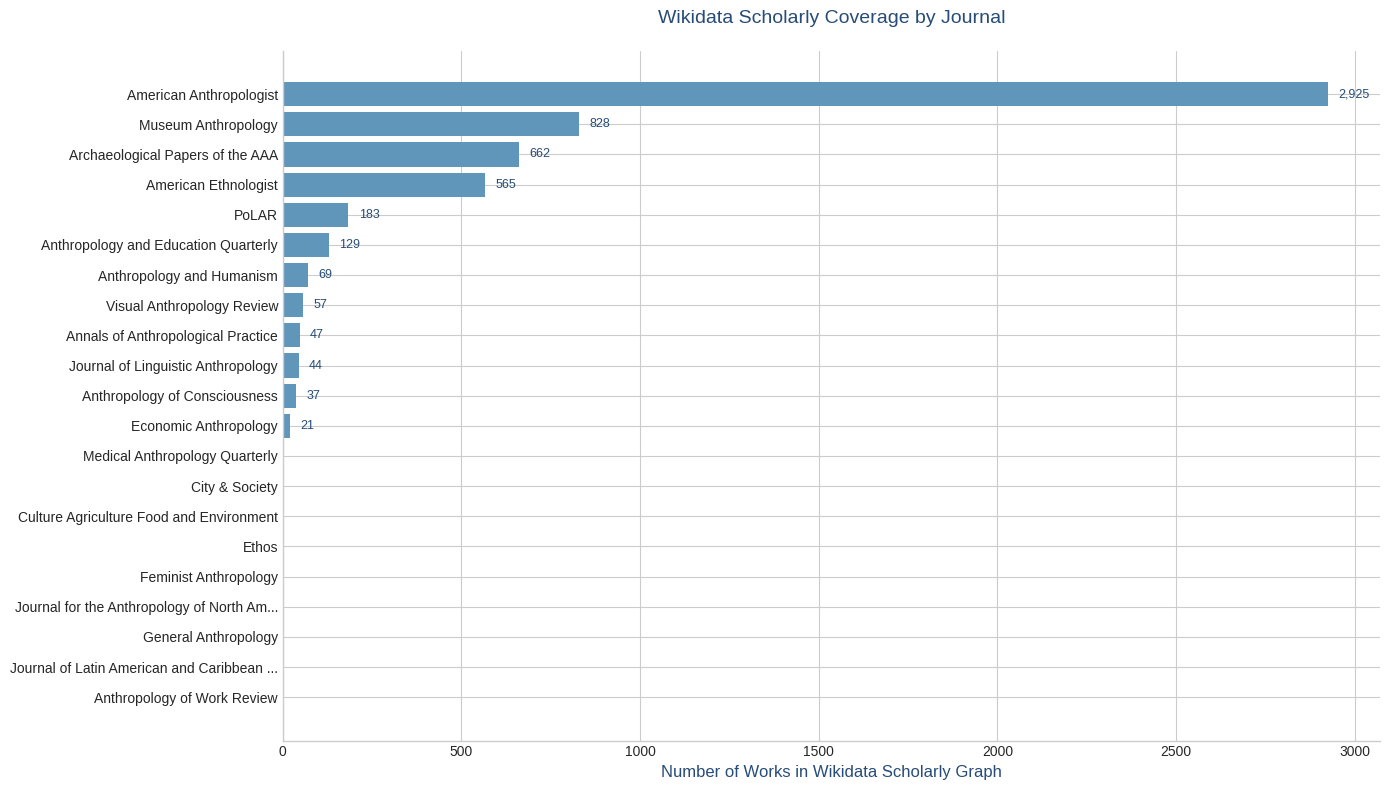


Complete Results:


,journalLabel,qid,article_count
0,American Anthropologist,Q4579783,2925
18,Museum Anthropology,Q15752491,828
7,Archaeological Papers of the AAA,Q15760478,662
1,American Ethnologist,Q15762644,565
19,PoLAR,Q63871800,183
3,Anthropology and Education Quarterly,Q15754091,129
4,Anthropology and Humanism,Q15755065,69
20,Visual Anthropology Review,Q27722507,57
2,Annals of Anthropological Practice,Q27724868,47
16,Journal of Linguistic Anthropology,Q15757220,44


In [7]:
def display_results():
    global results_df
    if results_df is None:
        print("No results to display. Please run the queries first.")
        return

    total_works = results_df['article_count'].sum()
    journals_with_works = (results_df['article_count'] > 0).sum()
    mean_works = results_df['article_count'].mean()
    median_works = results_df['article_count'].median()
    max_works = results_df['article_count'].max()

    display(HTML(f'''<div style="background-color: {COLORS['primary_bg']}; border-left: 5px solid {COLORS['primary_text']}; border-radius: 10px; padding: 20px; margin: 10px 0;">
        <h3 style="color: {COLORS['primary_text']}; margin-top: 0;">📊 Summary Statistics</h3>
        <div style="display: flex; flex-wrap: wrap; gap: 20px;">
            <div style="background-color: {COLORS['white']}; padding: 15px; border-radius: 8px; min-width: 150px;">
                <p style="margin: 0; color: {COLORS['neutral']}; font-size: 12px;">Total Works</p>
                <p style="margin: 5px 0 0 0; color: {COLORS['primary_text']}; font-size: 24px; font-weight: bold;">{total_works:,}</p></div>
            <div style="background-color: {COLORS['white']}; padding: 15px; border-radius: 8px; min-width: 150px;">
                <p style="margin: 0; color: {COLORS['neutral']}; font-size: 12px;">Journals with Works</p>
                <p style="margin: 5px 0 0 0; color: {COLORS['primary_text']}; font-size: 24px; font-weight: bold;">{journals_with_works} / {len(results_df)}</p></div>
            <div style="background-color: {COLORS['white']}; padding: 15px; border-radius: 8px; min-width: 150px;">
                <p style="margin: 0; color: {COLORS['neutral']}; font-size: 12px;">Mean Works/Journal</p>
                <p style="margin: 5px 0 0 0; color: {COLORS['primary_text']}; font-size: 24px; font-weight: bold;">{mean_works:,.1f}</p></div>
            <div style="background-color: {COLORS['white']}; padding: 15px; border-radius: 8px; min-width: 150px;">
                <p style="margin: 0; color: {COLORS['neutral']}; font-size: 12px;">Median Works</p>
                <p style="margin: 5px 0 0 0; color: {COLORS['primary_text']}; font-size: 24px; font-weight: bold;">{median_works:,.0f}</p></div>
        </div></div>'''))

    fig, ax = plt.subplots(figsize=(14, 8))
    plot_data = results_df.sort_values('article_count', ascending=True)
    labels = plot_data['journalLabel'].tolist() if 'journalLabel' in plot_data.columns else plot_data['qid'].tolist()
    labels = [str(l)[:40] + '...' if len(str(l)) > 40 else str(l) for l in labels]
    bars = ax.barh(labels, plot_data['article_count'], color=COLORS['interactive'])
    for bar, count in zip(bars, plot_data['article_count']):
        if count > 0:
            ax.text(bar.get_width() + max(max_works * 0.01, 5), bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=9, color=COLORS['primary_text'])
    ax.set_xlabel('Number of Works in Wikidata Scholarly Graph', fontsize=12, color=COLORS['primary_text'])
    ax.set_title('Wikidata Scholarly Coverage by Journal', fontsize=14, color=COLORS['primary_text'], pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    print("\nComplete Results:")
    display_cols = ['journalLabel', 'qid', 'article_count'] if 'journalLabel' in results_df.columns else ['qid', 'article_count']
    display(results_df[display_cols].sort_values('article_count', ascending=False))

display_results()

## Export Results

*Download the query results as a CSV file.*

In [ ]:
def export_results():
    global results_df
    if results_df is None:
        print("No results to export.")
        return
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'wikidata_scholarly_journal_counts_{timestamp}.csv'
    export_cols = ['qid', 'article_count', 'query_status']
    if 'journalLabel' in results_df.columns:
        export_cols = ['journalLabel'] + export_cols
    if 'issns' in results_df.columns:
        export_cols.append('issns')
    export_df = results_df[export_cols].copy()
    export_df['query_date'] = datetime.now().isoformat()
    export_df['endpoint'] = SCHOLARLY_ENDPOINT
    export_df.to_csv(filename, index=False)
    print(f"Saved: {filename} ({len(export_df)} journals)")

    if IN_COLAB:
        files.download(filename)
    else:
        print("(File saved to working directory)")

export_button = widgets.Button(description='Download CSV', button_style='primary', icon='download', layout=BUTTON_LAYOUT, style={'button_color': COLORS['interactive']})
export_output = widgets.Output()

def on_export_click(b):
    with export_output:
        clear_output()
        export_results()

export_button.on_click(on_export_click)
display(styled_container('<p style="color: ' + COLORS['neutral'] + ';">Download results as CSV including endpoint metadata.</p>', 'Export Results', ''))
display(export_button)
display(export_output)

---

## Batch Query: Retrieve All Articles with Metadata (Optional)

*For deeper analysis, retrieve full article metadata for all journals in a single query. This returns article titles, authors, publication dates, DOIs, and more.*

In [ ]:
def get_all_articles_batch(journal_qids, limit=10000):
    """
    Retrieve all articles with metadata for multiple journals in one query.
    Uses the scholarly endpoint with statement paths.
    """
    values_clause = " ".join([f"wd:{qid}" for qid in journal_qids])

    query = f"""
    SELECT
      ?journal ?journalLabel
      ?work ?workLabel
      ?title
      (GROUP_CONCAT(DISTINCT ?authorLabel; separator="; ") AS ?authors)
      ?pubDate
      ?doi
      ?volume
      ?issue
      ?pages
    WHERE {{
      VALUES ?journal {{ {values_clause} }}
      ?work p:P1433/ps:P1433 ?journal .
      OPTIONAL {{ ?work wdt:P1476 ?title . }}
      OPTIONAL {{ ?work wdt:P50 ?author . ?author rdfs:label ?authorLabel . FILTER(LANG(?authorLabel) = "en") }}
      OPTIONAL {{ ?work wdt:P577 ?pubDate . }}
      OPTIONAL {{ ?work wdt:P356 ?doi . }}
      OPTIONAL {{ ?work wdt:P478 ?volume . }}
      OPTIONAL {{ ?work wdt:P433 ?issue . }}
      OPTIONAL {{ ?work wdt:P304 ?pages . }}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    GROUP BY ?journal ?journalLabel ?work ?workLabel ?title ?pubDate ?doi ?volume ?issue ?pages
    ORDER BY ?journalLabel DESC(?pubDate)
    LIMIT {limit}
    """

    print(f"Querying scholarly endpoint for articles from {len(journal_qids)} journals...")
    print(f"Limit: {limit:,} results\n")

    result = query_wikidata(query, endpoint=SCHOLARLY_ENDPOINT, timeout=300)

    if result and 'results' in result and 'bindings' in result['results']:
        bindings = result['results']['bindings']
        if bindings:
            data = []
            for b in bindings:
                data.append({
                    'journal_qid': b.get('journal', {}).get('value', '').split('/')[-1],
                    'journal_name': b.get('journalLabel', {}).get('value', ''),
                    'work_qid': b.get('work', {}).get('value', '').split('/')[-1],
                    'work_label': b.get('workLabel', {}).get('value', ''),
                    'title': b.get('title', {}).get('value', ''),
                    'authors': b.get('authors', {}).get('value', ''),
                    'pub_date': b.get('pubDate', {}).get('value', '')[:10] if b.get('pubDate') else '',
                    'doi': b.get('doi', {}).get('value', ''),
                    'volume': b.get('volume', {}).get('value', ''),
                    'issue': b.get('issue', {}).get('value', ''),
                    'pages': b.get('pages', {}).get('value', '')
                })
            df = pd.DataFrame(data)
            print(f"Retrieved {len(df):,} articles")
            return df
    print("No results returned.")
    return None

# Uncomment to run:
# if journals_df is not None:
#     qids = journals_df['qid'].dropna().tolist()
#     articles_df = get_all_articles_batch(qids, limit=50000)
#     if articles_df is not None:
#         display(articles_df.head(20))

print("Batch query function loaded (optional — uncomment above to use).")